# 개요

- 회전은 벡터공간이 아니다. $R + \delta R$ 은 회전행렬이 아니므로 $x \leftarrow x + \delta$ 가 성립하지 않는다.
- 접평면에서 풀고 다양체로 되돌리는 `retraction`, 그리고 **좌/우 섭동 규약을 섞으면 무슨 일이 일어나는지** 를 확인한다.

# 1. 다양체 위의 최적화

- `벡터공간` $x \leftarrow x + \delta$
	- 덧셈이 닫혀 있다
- `SO(3)` $R \leftarrow R \boxplus \delta\theta$
	- 덧셈이 닫혀 있지 않다. 지수사상으로 되돌려야 한다

---
## 1.1. 문제 설정 — 점군 정합

$$ r_{i} = R p_{i} + t - q_{i} $$

- $p_i$: 원본 점, $q_i$: 대응점 (알려진 $R^{*}, t^{*}$ 로 옮긴 것)

$3N$ 개의 스칼라 잔차를 6개 자유도로 푸는 최소제곱이다.

---
## 1.2. Retraction

덧셈 대신 지수사상으로 되돌린다.

$$
\boxed{
R \leftarrow \exp\!\left([\delta\theta]_{\times}\right) R,
\qquad
t \leftarrow \exp\!\left([\delta\theta]_{\times}\right) t + \delta t
}
$$

이것이 **왼쪽(world) 섭동** 규약이다. `SLAM/LiDAR/BundleAdjustment.ipynb` 및 `05` 와 같다.

---
## 1.3. Jacobian — 규약이 정한다

왼쪽 섭동을 잔차에 넣고 1차까지 전개한다. $E = \exp([\delta\theta]_\times) \approx I + [\delta\theta]_{\times}$ 이므로:

$$
\begin{aligned}
r(\delta)
&= E(Rp_{i} + t) + \delta t - q_{i} \\
&\approx (Rp_{i} + t - q_{i}) + [\delta\theta]_{\times}(Rp_{i} + t) + \delta t \\
&= r_{i} - [Rp_{i} + t]_{\times}\,\delta\theta + \delta t
\end{aligned}
$$

두 번째 줄에서 세 번째 줄로 갈 때 $[a]_{\times}b = -[b]_{\times}a$ 를 썼다. 따라서:

$$
\boxed{
J_{i}^{\text{left}}
= \frac{\partial r_{i}}{\partial[\delta\theta,\ \delta t]}
= \begin{bmatrix} -[Rp_{i} + t]_{\times} & I \end{bmatrix}
\quad (3 \times 6)
}
$$

즉,

> 회전의 미분은 **회전 후 점**의 skew이지, 회전 전 점의 skew가 아니다

오른쪽 섭동 $R \leftarrow R\exp([\delta\phi]_{\times})$, $t \leftarrow t + R\,\delta t$ 를 쓰면 답이 달라진다.

$$ J_{i}^{\text{right}} = \begin{bmatrix} -R[p_{i}]_{\times} & R \end{bmatrix} $$

**둘 다 옳지만 섞으면 둘 다 틀린다.** 어느 쪽을 쓰는지 노트북 맨 위에 적고 끝까지 그것만 쓴다.

---
## 1.4. 전체 파이프라인

$$ \boxed{ r \rightarrow J = [-[Rp+t]_{\times}\ \ I] \rightarrow H\delta = -g \rightarrow R \leftarrow \exp([\delta\theta]_{\times})R,\ t \leftarrow \exp([\delta\theta]_{\times})t + \delta t } $$

```txt
   접평면 (R^6)                  다양체 SO(3) x R^3
       |                              |
   d = [dtheta, dt]  --- exp() --->   R, t 갱신
       ^                              |
       |                              v
   H d = -g  <--- J, r  <---------  현재 R, t
```

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

# numpy 2.x + Apple Accelerate 조합에서 matmul 이 부동소수점 상태 플래그를 잘못 남긴다.
# 결과값은 전부 정상이라(직접 대조해 확인했다) 이 조합에서만 나오는 잡음만 끈다.
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)


def pick_korean_font():
    """한글과 수학 마이너스(U+2212)를 **둘 다** 가진 폰트를 우선 고른다.

    로그 축 눈금은 $\mathdefault{10^{-13}}$ 로 그려지는데, mathtext 는 여기서 font.family 를
    쓴다. AppleGothic 계열에는 U+2212 가 없어서 지수의 마이너스가 네모로 깨진다 —
    한글은 멀쩡해서 알아채기 어렵다.
    """
    available = {f.name for f in font_manager.fontManager.ttflist}
    candidates = ("Arial Unicode MS", "Noto Sans CJK KR", "NanumGothic",
                  "Malgun Gothic", "Apple SD Gothic Neo", "AppleGothic")
    fallback = None
    for name in candidates:
        if name not in available:
            continue
        fallback = fallback or name
        try:
            path = font_manager.findfont(font_manager.FontProperties(family=name),
                                         fallback_to_default=False)
            if font_manager.get_font(path).get_char_index(0x2212):
                return name, True
        except Exception:
            continue
    return fallback, False


_font, _has_minus = pick_korean_font()
if _font:
    plt.rcParams["font.family"] = _font
    plt.rcParams["axes.unicode_minus"] = _has_minus   # 없으면 ASCII 하이픈으로 대체
    plt.rcParams["mathtext.fontset"] = "dejavusans"
print(f"font: {_font}  (U+2212 보유: {_has_minus})")

font: Arial Unicode MS  (U+2212 보유: True)


## 0. 샘플 데이터 생성하기

- 알려진 $(R^{*}, t^{*})$ 로 옮긴 점군 쌍. 대응은 이미 알고 있다고 본다(대응 탐색은 이 노트북의 주제가 아니다).
- 초기값은 참값을 회전·평행이동으로 크게 흔든 것이다.

In [2]:
import importlib
import problems
importlib.reload(problems)                 # 커널을 재시작하지 않아도 최신 버전을 반영
from problems import *

P, Q, R_true, t_true, R_init, t_init = make_registration_data(n_points=200, noise=0.005, seed=0)

print("점 %d 개" % len(P))
print("초기 회전 오차 : %.4f rad" % np.linalg.norm(so3_log(R_init @ R_true.T)))
print("초기 평행이동 오차: %.4f" % np.linalg.norm(t_init - t_true))

점 200 개
초기 회전 오차 : 0.3133 rad
초기 평행이동 오차: 0.4782


# 1. 데이터 시각화

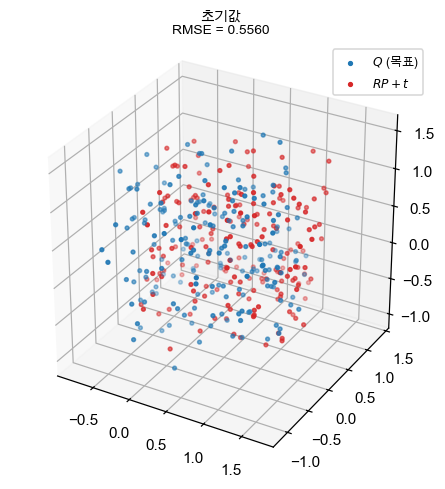

In [3]:
def show_clouds(P, Q, R, t, title):
    """P 를 (R, t) 로 옮긴 것과 Q 를 겹쳐 그린다. 정합되면 두 색이 포개진다."""
    P_moved = P @ R.T + t                          # (N, 3)
    fig = plt.figure(figsize=(5.4, 4.4))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(Q[:, 0], Q[:, 1], Q[:, 2], s=6, c="tab:blue", label="$Q$ (목표)")
    ax.scatter(P_moved[:, 0], P_moved[:, 1], P_moved[:, 2], s=6, c="tab:red",
               label="$RP + t$")
    allp = np.vstack([Q, P_moved])
    c, h = allp.mean(0), 0.5 * np.ptp(allp, axis=0).max()
    ax.set_xlim(c[0] - h, c[0] + h); ax.set_ylim(c[1] - h, c[1] + h); ax.set_zlim(c[2] - h, c[2] + h)
    ax.set_box_aspect((1, 1, 1))
    rmse = np.sqrt(np.mean(np.sum((P_moved - Q) ** 2, axis=1)))
    ax.set_title(f"{title}\nRMSE = {rmse:.4f}", fontsize=9)
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()


show_clouds(P, Q, R_init, t_init, "초기값")

# 2. Gauss-Newton on SO(3)

In [4]:
# 1. 잔차 - r_i = R p_i + t - q_i
def registration_residual(R, t, P, Q):
    """(N, 3) -> 평탄화한 (3N,). 최소제곱은 벡터 하나로 다룬다."""
    return (P @ R.T + t - Q).reshape(-1)

In [5]:
# 2. Jacobian (왼쪽 섭동) - J_i = [ -[R p_i + t]_x   I ]
def registration_jacobian_left(R, t, P):
    """(3N, 6). 회전 블록은 **회전 후** 점의 skew 다."""
    P_moved = P @ R.T + t                          # (N, 3)
    # (N, 3, 3) — 회전 블록
    J_rot = -skew(P_moved)
    # (N, 3, 3) — 평행이동 블록은 단위행렬
    J_trans = np.broadcast_to(np.eye(3), (len(P), 3, 3))
    # (N, 3, 6) -> (3N, 6)
    return np.concatenate([J_rot, J_trans], axis=2).reshape(-1, 6)


def registration_jacobian_right(R, t, P):
    """오른쪽 섭동 R <- R exp(dphi), t <- t + R dt 를 쓸 때의 Jacobian. 비교용이다."""
    J_rot = -np.einsum("ij,njk->nik", R, skew(P))              # (N, 3, 3)
    J_trans = np.broadcast_to(R, (len(P), 3, 3))               # (N, 3, 3)
    return np.concatenate([J_rot, J_trans], axis=2).reshape(-1, 6)

In [6]:
# 3. retraction - R <- exp(dtheta) R, t <- exp(dtheta) t + dt   (왼쪽 섭동)
def retract_left(R, t, delta):
    E = so3_exp(delta[:3])                         # (3, 3)
    return E @ R, E @ t + delta[3:]


def retract_right(R, t, delta):
    """오른쪽 섭동의 짝. Jacobian 과 반드시 같은 규약이어야 한다."""
    return R @ so3_exp(delta[:3]), t + R @ delta[3:]

## 2.1. 메인 루프

번호 주석이 1.4절 파이프라인과 대응한다.

In [7]:
R, t = R_init.copy(), t_init.copy()
rot_err, trans_err, costs = [], [], []

for it in range(15):
    # 1. 잔차
    r = registration_residual(R, t, P, Q)          # (3N,)
    costs.append(0.5 * float(r @ r))
    rot_err.append(np.linalg.norm(so3_log(R @ R_true.T)))
    trans_err.append(np.linalg.norm(t - t_true))

    # 2. Jacobian (왼쪽 섭동)
    J = registration_jacobian_left(R, t, P)        # (3N, 6)

    # 3. Normal equation
    H = J.T @ J                                    # (6, 6)
    g = J.T @ r                                    # (6,)
    delta = np.linalg.solve(H, -g)

    # 4. retraction - 같은 규약으로 되돌린다
    R, t = retract_left(R, t, delta)

print("F: %.6e -> %.6e" % (costs[0], costs[-1]))
print("회전 오차   : %.4e rad" % np.linalg.norm(so3_log(R @ R_true.T)))
print("평행이동 오차: %.4e" % np.linalg.norm(t - t_true))

F: 3.091250e+01 -> 6.689816e-03
회전 오차   : 4.2723e-04 rad
평행이동 오차: 1.3287e-03


# 3. 검증

## 3.1. 해석 Jacobian이 맞는가

**이 한 셀이 이 노트북에서 가장 중요하다.** 섭동 규약 실수는 수식이 멀쩡해 보여서 눈으로는
잡히지 않는다. 중앙차분과 대조하면 바로 걸린다.

In [8]:
def numeric_jacobian(R, t, P, Q, retract, h=1e-6):
    """retraction 을 통해 섭동을 주고 중앙차분. (3N, 6)

    delta 를 직접 R 에 더하는 게 아니라 **retraction 으로** 준다는 점이 핵심이다.
    그래야 다양체 위에 머문다.
    """
    J = np.zeros((3 * len(P), 6))
    for k in range(6):
        d = np.zeros(6); d[k] = h
        R_p, t_p = retract(R, t, d)
        R_m, t_m = retract(R, t, -d)
        J[:, k] = (registration_residual(R_p, t_p, P, Q)
                   - registration_residual(R_m, t_m, P, Q)) / (2 * h)
    return J


R_test, t_test = R_init, t_init                    # 해가 아닌 점에서 재야 의미가 있다

print(f"{'규약 조합':34s} {'최대 오차':>12s}   판정")
checks = [
    ("left  J  vs  left  retraction", registration_jacobian_left, retract_left),
    ("right J  vs  right retraction", registration_jacobian_right, retract_right),
    ("left  J  vs  right retraction", registration_jacobian_left, retract_right),
    ("right J  vs  left  retraction", registration_jacobian_right, retract_left),
]
for label, jac, retract in checks:
    J_a = jac(R_test, t_test, P)
    J_n = numeric_jacobian(R_test, t_test, P, Q, retract)
    err = np.abs(J_a - J_n).max()
    print(f"{label:34s} {err:12.3e}   {'OK' if err < 1e-6 else '틀렸다'}")

규약 조합                                     최대 오차   판정
left  J  vs  left  retraction         1.939e-10   OK
right J  vs  right retraction         2.697e-10   OK
left  J  vs  right retraction         7.996e-01   틀렸다
right J  vs  left  retraction         7.996e-01   틀렸다


**규약을 맞춰 쓴 두 조합만 통과하고, 섞은 두 조합은 최대 오차 0.8 로 실패한다.** 그런데 실패한
Jacobian도 그 자체로는 완벽히 정상적인 $3N \times 6$ 행렬이라, 출력을 봐서는 알 수 없다.

그러면 틀린 Jacobian으로 최적화를 돌리면 터질까? **아니다.** 아래가 이 노트북에서 가장
오래 기억해야 할 부분이다.

In [9]:
def run_registration(jac, retract, iters=25, lam=1e-12, target=6.7e-3):
    """Jacobian 과 retraction 을 짝으로 받아 GN 을 돈다.

    반환: (비용 이력, target 에 처음 도달한 반복 번호)
    """
    R, t = R_init.copy(), t_init.copy()
    hist, reached = [], None

    for k in range(iters):
        r = registration_residual(R, t, P, Q)
        F = 0.5 * float(r @ r)
        hist.append(F)
        if reached is None and F <= target:
            reached = k

        J = jac(R, t, P)
        H = J.T @ J
        try:
            delta = np.linalg.solve(H + lam * np.diag(np.diag(H)), -J.T @ r)
        except np.linalg.LinAlgError:
            break
        if not np.all(np.isfinite(delta)):
            break
        R, t = retract(R, t, delta)

    return hist, reached


runs = {}
print(f"{'규약 조합':34s} {'수렴 반복':>8s}   비용 이력 (처음 6회)")
for label, jac, retract in checks:
    hist, reached = run_registration(jac, retract)
    runs[label] = hist
    print(f"{label:34s} {str(reached):>8s}   " + " ".join(f"{v:.2e}" for v in hist[:6]))

규약 조합                                 수렴 반복   비용 이력 (처음 6회)
left  J  vs  left  retraction             2   3.09e+01 9.24e-02 6.69e-03 6.69e-03 6.69e-03 6.69e-03
right J  vs  right retraction             2   3.09e+01 1.07e-02 6.69e-03 6.69e-03 6.69e-03 6.69e-03
left  J  vs  right retraction            12   3.09e+01 7.23e+00 2.34e+00 7.70e-01 2.48e-01 7.86e-02
right J  vs  left  retraction            12   3.09e+01 8.87e+00 3.22e+00 1.06e+00 3.28e-01 9.89e-02


**섞어도 수렴한다.** 같은 최소점에, 같은 비용으로. 다만 **2회가 12회로 늘었다.**

이유는 틀린 $J$ 도 여전히 내리막 방향을 주기 때문이다. $J^{T}J$ 가 양정부호인 한 $\delta$ 는
비용을 줄이는 쪽을 가리킨다. 다만 그것이 더 이상 Newton 스텝이 아니라서, **2차 수렴이 1차로
떨어진다.** 비용 이력을 보면 맞춘 쪽은 한 번에 자릿수를 건너뛰고, 섞은 쪽은 매번 3배씩만 준다.

즉,

> 규약을 섞으면 터지지 않는다. 느려질 뿐이라 solver 탓으로 착각하게 된다

작은 문제에서는 반복 몇 번 더 도는 것으로 끝나 알아채지 못한다. 수천 개 pose를 도는 BA에서는
그 차이가 몇 시간이 되고, 그때는 원인을 Jacobian 규약에서 찾지 않는다.
**중앙차분 대조가 유일한 방어선이다.**

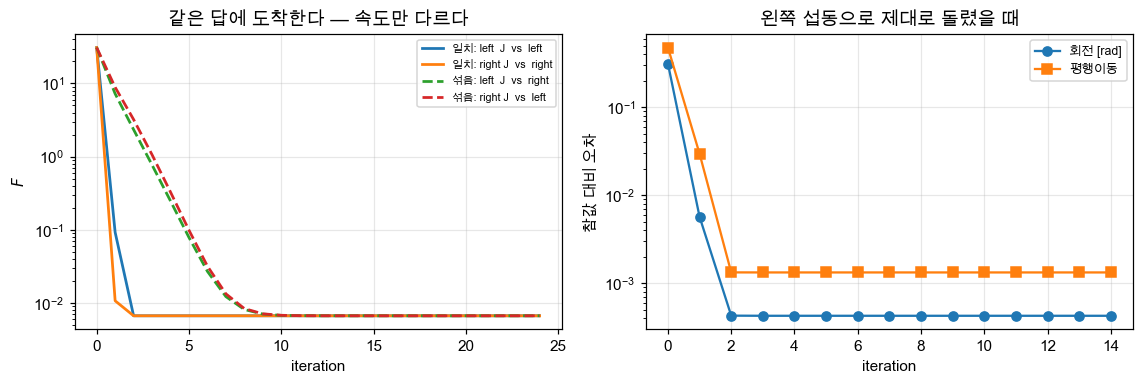

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))

for label, hist in runs.items():
    mixed = label.split()[0] != label.split()[3]
    axes[0].semilogy(np.maximum(hist, 1e-20), "--" if mixed else "-", lw=1.8,
                     label=("섞음: " if mixed else "일치: ") + label.replace(" retraction", ""))
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("$F$")
axes[0].set_title("같은 답에 도착한다 — 속도만 다르다"); axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=7)

axes[1].semilogy(rot_err, "o-", label="회전 [rad]")
axes[1].semilogy(trans_err, "s-", label="평행이동")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("참값 대비 오차")
axes[1].set_title("왼쪽 섭동으로 제대로 돌렸을 때"); axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

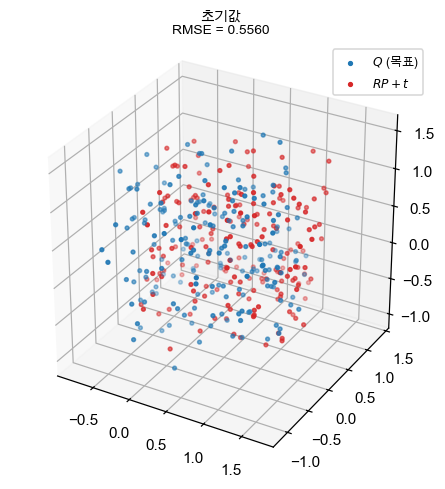

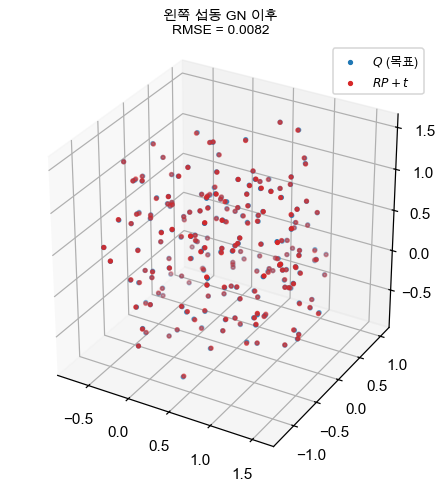

In [11]:
# before / after - 같은 함수, 같은 축
show_clouds(P, Q, R_init, t_init, "초기값")
show_clouds(P, Q, R, t, "왼쪽 섭동 GN 이후")

## 3.2. 한계

- 대응 $(p_i, q_i)$ 를 이미 안다고 가정했다. 실제 ICP는 매 반복 대응을 다시 찾고, 그 단계가
  수렴의 대부분을 좌우한다 — `SLAM/LiDAR/BundleAdjustment.ipynb` 참고.
- 점군 정합은 $R, t$ 를 SVD로 닫힌 형태로 풀 수 있다(Kabsch/Umeyama). 여기서 반복법을 쓴 것은
  **다양체 Jacobian을 검산하기 위한 연습**이지, 이 문제에 GN이 최선이라서가 아니다.
- `so3_exp` 는 $\|\phi\| \to 0$ 에서 1차 근사로 떨어진다. 더 엄밀하게는 Taylor 전개 항을
  써야 하지만, 이 문제의 스케일에서는 차이가 없다.
- $\log$ 는 $\|\phi\| \to \pi$ 근처에서 불안정하다. 초기 회전 오차를 $\pi$ 가까이 주면 채점용
  `so3_log` 자체가 먼저 망가진다.